## 1. Préparation et séparation des données Train/Test

**Objectif :** 
Charger le jeu de données nettoyé et le séparer en un jeu d'entraînement (80%) et un jeu de test (20%).

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Remplacer 'cleaned_loan.csv' par 'transformed_loan.csv'
df = pd.read_csv('../data/processed/transformed_loan.csv')

X = df.drop(columns=['Loan_Status'])
y = df['Loan_Status']

# Division en jeux d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Taille de X_train : {X_train.shape}")
print(f"Taille de X_test  : {X_test.shape}")

Taille de X_train : (491, 19)
Taille de X_test  : (123, 19)


# 2. Entraînement du modèle de Régression Logistique

**Objectif :**
Instancier et entraîner le modèle sur les données d'entraînement.

In [3]:
# Instanciation et entraînement du modèle
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Prédictions sur le jeu de test
y_pred = model.predict(X_test)

# Évaluation des performances
print("--- Performances du Modèle ---")
print(f"Accuracy : {accuracy_score(y_test, y_pred):.2f}\n")
print("Rapport de classification :")
print(classification_report(y_test, y_pred))

--- Performances du Modèle ---
Accuracy : 0.85

Rapport de classification :
              precision    recall  f1-score   support

           0       0.92      0.58      0.71        38
           1       0.84      0.98      0.90        85

    accuracy                           0.85       123
   macro avg       0.88      0.78      0.81       123
weighted avg       0.86      0.85      0.84       123



## 3. Comparaison de plusieurs algorithmes de classification

**Objectif :**
Comparer les performances de la Régression Logistique avec d'autres classifieurs classiques :
- **Arbre de décision** (*Decision Tree*)
- **Forêt aléatoire** (*Random Forest*)
- **Gradient Boosting** (*Gradient Boosting Classifier*)
- **Support Vector Machine** (*SVM*)

**Métrique d'évaluation principale :** L'Accuracy (précision globale) et le F1-Score.

In [4]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score
import pandas as pd

# Dictionnaire regroupant les différents modèles
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "SVM": SVC(random_state=42)
}

results = []

# Entraînement et évaluation de chaque modèle
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    results.append({
        "Modèle": name,
        "Accuracy": round(acc, 4),
        "F1-Score": round(f1, 4)
    })

# Création d'un DataFrame récapitulatif
df_results = pd.DataFrame(results).sort_values(by="Accuracy", ascending=False)
df_results

,Modèle,Accuracy,F1-Score
0,Logistic Regression,0.8537,0.9022
2,Random Forest,0.8537,0.8977
3,Gradient Boosting,0.8537,0.8989
4,SVM,0.8455,0.8984
1,Decision Tree,0.7073,0.7722


## 4. Visualisation comparative des performances

**Objectif :**
Afficher un graphique à barres pour comparer visuellement la précision de chaque modèle sur le jeu de test.

C:\Users\MINA\AppData\Local\Temp\ipykernel_17040\2220541161.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_results, x="Accuracy", y="Modèle", palette="magma")


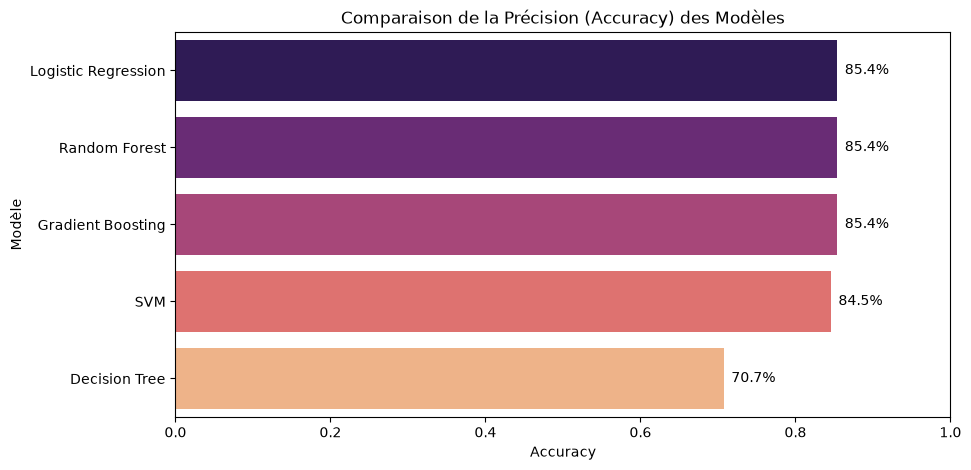

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
sns.barplot(data=df_results, x="Accuracy", y="Modèle", palette="magma")
plt.title("Comparaison de la Précision (Accuracy) des Modèles")
plt.xlim(0, 1)
for index, value in enumerate(df_results["Accuracy"]):
    plt.text(value + 0.01, index, f"{value*100:.1f}%", va='center')
plt.show()

## 5. Analyse détaillée du meilleur modèle (Matrice de Confusion)

**Objectif :**
Visualiser les vrais positifs, vrais négatifs, faux positifs et faux négatifs du modèle ayant obtenu le meilleur score.

--- Détail pour Logistic Regression ---
Vrais Négatifs (VN) : 22
Faux Positifs (FP)  : 16
Faux Négatifs (FN)  : 2
Vrais Positifs (VP) : 83



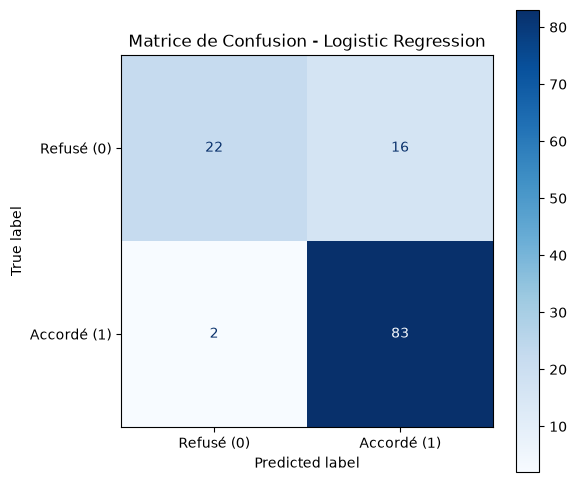

In [6]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Sélection du premier modèle du classement
best_model_name = df_results.iloc[0]["Modèle"]
best_model = models[best_model_name]

# 2. Génération des prédictions
y_pred_best = best_model.predict(X_test)

# 3. Calcul et extraction des valeurs (VN, FP, FN, VP)
cm = confusion_matrix(y_test, y_pred_best)
vn, fp, fn, vp = cm.ravel()

print(f"--- Détail pour {best_model_name} ---")
print(f"Vrais Négatifs (VN) : {vn}")
print(f"Faux Positifs (FP)  : {fp}")
print(f"Faux Négatifs (FN)  : {fn}")
print(f"Vrais Positifs (VP) : {vp}\n")

# 4. Affichage de la matrice de confusion graphique
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Refusé (0)", "Accordé (1)"])

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap="Blues", ax=ax)
plt.title(f"Matrice de Confusion - {best_model_name}")
plt.show()

## 6. Sauvegarde du meilleur modèle

**Objectif :**
Sérialiser le meilleur modèle entraîné dans le dossier `models/` sous le nom `model.pkl` afin de pouvoir l'utiliser plus tard dans l'application (`app.py`).

In [7]:
import joblib
import os

os.makedirs('../models', exist_ok=True)

# Sauvegarde du modèle
joblib.dump(best_model, '../models/model.pkl')
print(f" Le modèle '{best_model_name}' a été sauvegardé avec succès dans 'models/model.pkl' !")

 Le modèle 'Logistic Regression' a été sauvegardé avec succès dans 'models/model.pkl' !
